<a href="https://colab.research.google.com/github/jose-luis-hernandez-amaya/Simulaci-n-1/blob/main/Sistema_linea_de_espera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import random as r
import matplotlib.pyplot as plt

In [44]:
def fila(tiempo_total, tasa_llegada, tasa_servicio):
    t = 0
    N_A = 0 # Contador de llegadas
    N_D = 0 # Contador de salidas
    n = 0   # Clientes físicamente en el sistema

    t_A = r.expovariate(tasa_llegada)
    t_D = float('inf') # Infinito porque el sistema empieza vacío

    tiempos_historico = [0]
    clientes_historico = [0]

    while t <= tiempo_total:

        # ¿Qué pasa primero? ¿Una llegada o una salida?
        if t_A <= t_D and t_A <= tiempo_total:
            #Llegada
            t = t_A
            N_A += 1
            n += 1
            t_A = t + r.expovariate(tasa_llegada)

            if n == 1:
                # Si el sistema estaba vacío, el cliente pasa directo a servicio
                t_D = t + r.expovariate(tasa_servicio)

        elif t_D < t_A and t_D <= tiempo_total:
            #Salida
            t = t_D
            N_D += 1
            n -= 1

            if n == 0:
                # El sistema se volvió a vaciar
                t_D = float('inf')
            else:
                # Hay alguien esperando en la fila, lo pasamos al servidor
                t_D = t + r.expovariate(tasa_servicio)

        else:
            break

        tiempos_historico.append(t)
        clientes_historico.append(n)

    return tiempos_historico, clientes_historico


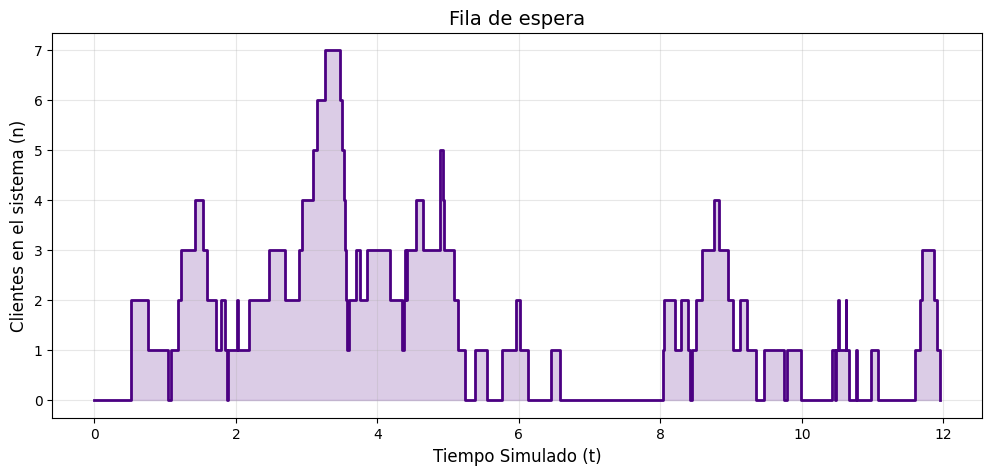

In [45]:
llegadas = 4  # λ
servicio = 6  # μ
tiempo_sim = 12

T, N = fila(tiempo_total=tiempo_sim, tasa_llegada=llegadas, tasa_servicio=servicio)

plt.figure(figsize=(12, 5))
plt.step(T, N, where='post', color='indigo', linewidth=2)
plt.fill_between(T, 0, N, step="post", alpha=0.2, color='indigo')
plt.xlabel('Tiempo Simulado (t)', fontsize=12)
plt.ylabel('Clientes en el sistema (n)', fontsize=12)
plt.title('Fila de espera', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
lam = llegadas  # λ
mu = servicio   # μ

if lam < mu:
    # rho
    rho = lam / mu
    print(f"Factor de utilización (rho): {rho:.4f}")

    # P0
    P0 = 1 - rho
    print(f"Probabilidad de que el sistema esté vacío (P0): {P0:.4f}")

    # Pn
    n_ejemplo = 3
    Pn = (rho ** n_ejemplo) * P0
    print(f"Probabilidad de que haya exactamente {n_ejemplo} clientes (P{n_ejemplo}): {Pn:.4f}")

    # Lq
    Lq = (lam ** 2) / (mu * (mu - lam))
    print(f"Número promedio de unidades en cola (Lq): {Lq:.4f}")

    # Ls
    Ls = Lq + (lam / mu)
    print(f"Número promedio de unidades en el sistema (Ls): {Ls:.4f}")

    # Wq
    Wq = Lq / lam
    print(f"Tiempo promedio que una unidad pasa en cola (Wq): {Wq:.4f}")

else:
    print("SISTEMA INESTABLE: La tasa de llegadas (λ) es mayor o igual a la tasa de servicio (μ).")
    print("La fila crecerá hasta el infinito y las fórmulas de estado estable no aplican.")

Factor de utilización (rho): 0.6667
Probabilidad de que el sistema esté vacío (P0): 0.3333
Probabilidad de que haya exactamente 3 clientes (P3): 0.0988
Número promedio de unidades en cola (Lq): 1.3333
Número promedio de unidades en el sistema (Ls): 2.0000
Tiempo promedio que una unidad pasa en cola (Wq): 0.3333
